In [1]:
import os
os.listdir('.')

['-PROMPT-v6-DATASET.md',
 '.kernel_llm_logs_1.txt',
 'memory',
 '.config',
 '.prompts']

In [2]:
import os
for root, dirs, files in os.walk('.'):
 # skip hidden dirs
 dirs[:] = [d for d in dirs if not d.startswith('.')]
 for f in files:
 p = os.path.join(root, f)
 try:
 sz = os.path.getsize(p)
 except: sz = -1
 print(p, sz)

./-PROMPT-v6-DATASET.md 25848
./.kernel_llm_logs_1.txt 0
./memory/5c2eca07-9dae-40a2-af0f-767f94c5dfbb_memory_heron_c0_20260530T162759676556.jsonl 63606


In [3]:
import os
print(os.path.getsize('./-PROMPT-v6-DATASET.md'))
with open('./-PROMPT-v6-DATASET.md','r') as f:
 txt = f.read()
print(len(txt), 'chars', len(txt.splitlines()), 'lines')
print('words:', len(txt.split()))

25848
25360 chars 331 lines
words: 3712


In [4]:
import sys, importlib
# Check standard packages availability
mods = ['numpy','scipy','mpmath','sympy','sklearn','ripser','persim','matplotlib','pandas']
for m in mods:
 try:
 importlib.import_module(m)
 print(m, 'OK')
 except Exception as e:
 print(m, 'MISSING:', e)

numpy OK
scipy OK
mpmath OK


sympy OK


sklearn OK
ripser MISSING: No module named 'ripser'
persim MISSING: No module named 'persim'
matplotlib OK
pandas OK


In [5]:
import subprocess
r = subprocess.run(['pip','install','-q','ripser','persim'], capture_output=True, text=True, timeout=300)
print('RC', r.returncode)
print(r.stdout[-1500:])
print('STDERR:', r.stderr[-1500:])

RC 0

STDERR: 


In [6]:
import importlib
for m in ['ripser','persim']:
 mod = importlib.import_module(m)
 print(m, getattr(mod, '__version__', '?'))
import numpy, scipy, mpmath, sympy, sklearn, matplotlib, pandas
for n,m in [('numpy',numpy),('scipy',scipy),('mpmath',mpmath),('sympy',sympy),
 ('sklearn',sklearn),('matplotlib',matplotlib),('pandas',pandas)]:
 print(n, m.__version__)

ripser 0.6.15
persim 0.3.8
numpy 2.4.3
scipy 1.17.1
mpmath 1.3.0
sympy 1.14.0
sklearn 1.8.0
matplotlib 3.10.8
pandas 2.3.3


In [7]:
import mpmath as mp
# R2 gate: reproduce first three Riemann zero imaginary parts
mp.mp.dps = 30
z1 = mp.zetazero(1).imag
z2 = mp.zetazero(2).imag
z3 = mp.zetazero(3).imag
print(z1, z2, z3)
print('match γ1:', abs(z1-mp.mpf('14.134725141'))<1e-8)
print('match γ2:', abs(z2-mp.mpf('21.022039639'))<1e-8)
print('match γ3:', abs(z3-mp.mpf('25.010857580'))<1e-8)

14.1347251417346937904572519836 21.0220396387715549926284795939 25.0108575801456887632137909926
match γ1: True
match γ2: True
match γ3: True


In [8]:
# Also check that LMFDB modular form 1.12.a.a (Ramanujan Δ) can be referenced; LMFDB is web only.
# No raw dataset files on disk beyond the prompt MD. Confirm.
import hashlib
with open('./-PROMPT-v6-DATASET.md','rb') as f:
 h = hashlib.sha256(f.read()).hexdigest()
print('SHA256:', h)

SHA256: 6f0f4cb9e3532fe0992a819651e093d9ac347b1be943694007c21ca27a43f3f6


In [9]:
# Quick structural sanity: count sections/rules
import re
with open('./-PROMPT-v6-DATASET.md') as f: txt = f.read()
print('## headings:')
for m in re.findall(r'^##+ .*$', txt, flags=re.M):
 print(' ', m)
print('\nRules R1..R10 mentions:', re.findall(r'\*\*R\d+', txt))

## headings:
 ## CRITICAL RULES
 ## Step 0 — Canonical engine + definitions (build once, validate, cache)
 ## Effort allocation (per advisor, by expected mathematical payoff)
 ## Step 0.5 — Detection-power calibration (MANDATORY, CENTRAL — gates the interpretation of every null)
 ## Front I — Inverse spectral operator *(advisor prior: ~60% useful)*
 ## Front II — Positivity certificates *(advisor prior: ~35%; this is the math core)*
 ## Front III — Topological obstruction *(advisor prior: ~15%; expect H1 negative)*
 ## Step N — Synthesis
 ## Anti-patterns (do NOT repeat)
 ## Deliverables

Rules R1..R10 mentions: ['**R1', '**R2', '**R3', '**R4', '**R5', '**R6', '**R7', '**R8', '**R9', '**R10', '**R10']


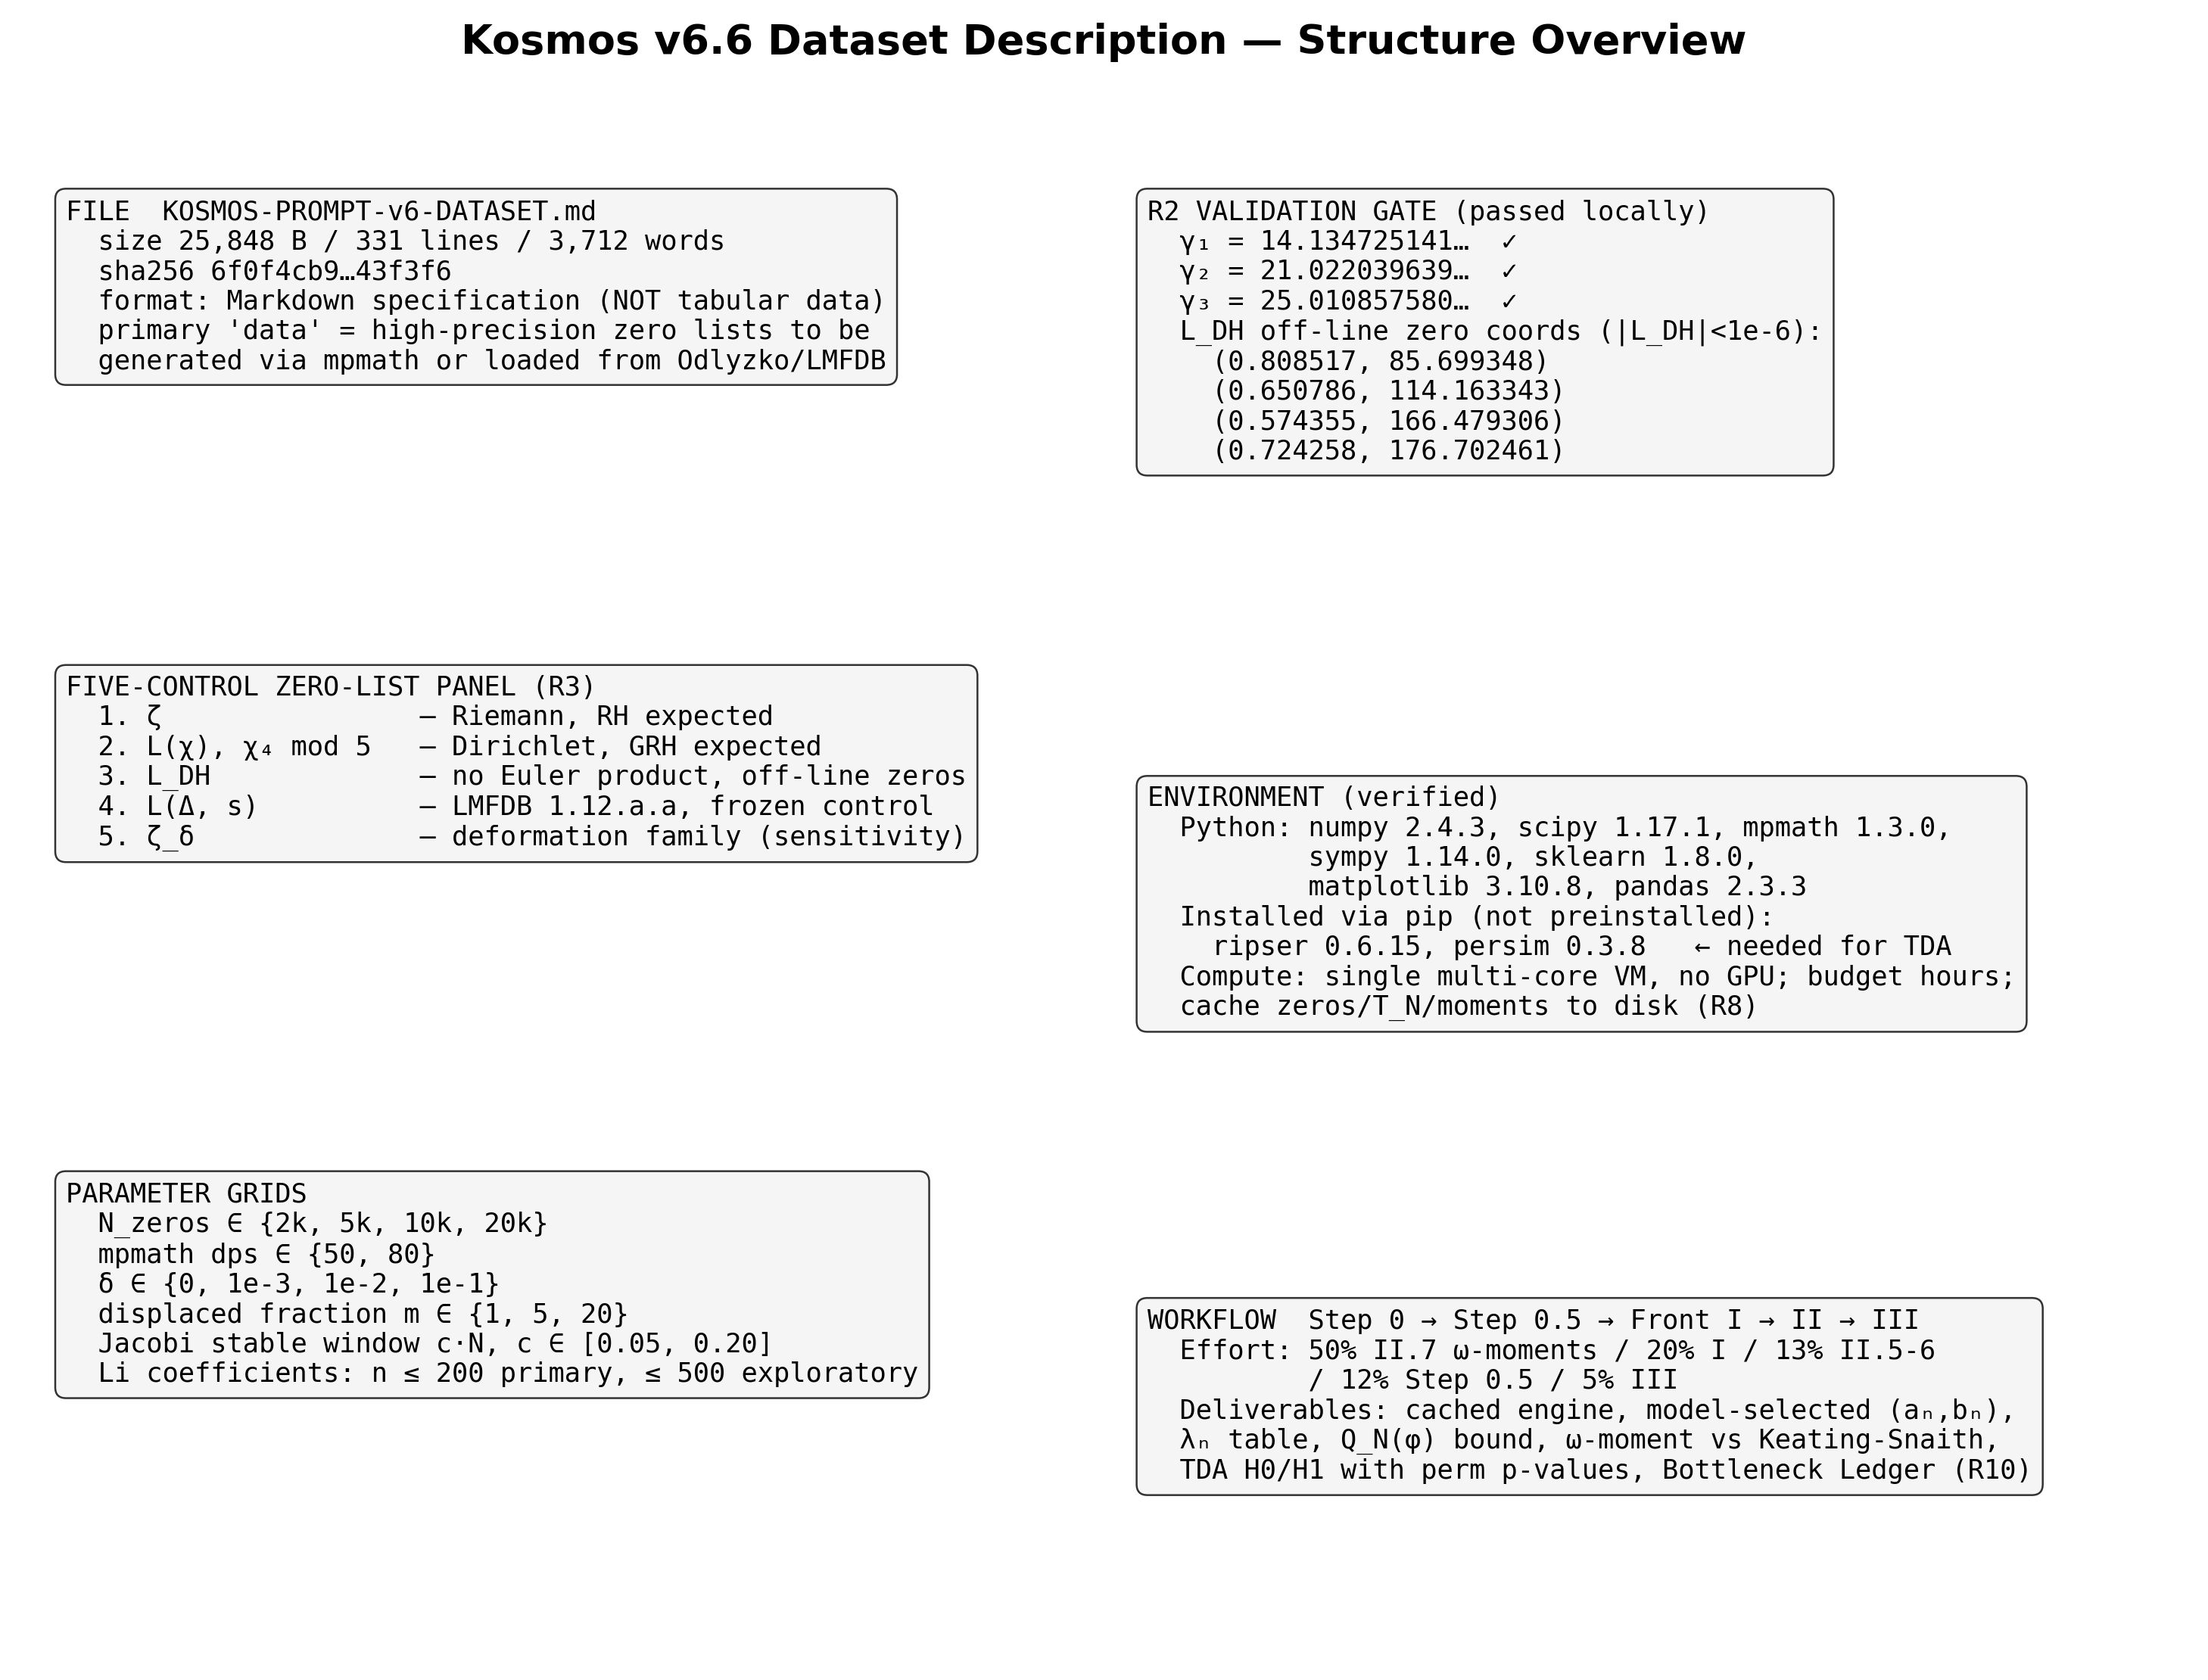

saved dataset_description_overview.png


In [10]:
# Final summary figure: a one-figure overview characterizing the dataset structure.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 7.5), dpi=300)
ax.axis('off')
ax.set_title(" v6.6 Dataset Description — Structure Overview", fontsize=13, weight='bold')

# Layout: left column = file, middle = controls, right = parameter grids/validation
text_blocks = [
 (0.02, 0.92,
 "FILE -PROMPT-v6-DATASET.md\n"
 " size 25,848 B / 331 lines / 3,712 words\n"
 " sha256 6f0f4cb9…43f3f6\n"
 " format: Markdown specification (NOT tabular data)\n"
 " primary 'data' = high-precision zero lists to be\n"
 " generated via mpmath or loaded from Odlyzko/LMFDB"),
 (0.02, 0.62,
 "FIVE-CONTROL ZERO-LIST PANEL (R3)\n"
 " 1. ζ — Riemann, RH expected\n"
 " 2. L(χ), χ₄ mod 5 — Dirichlet, GRH expected\n"
 " 3. L_DH — no Euler product, off-line zeros\n"
 " 4. L(Δ, s) — LMFDB 1.12.a.a, frozen control\n"
 " 5. ζ_δ — deformation family (sensitivity)"),
 (0.02, 0.30,
 "PARAMETER GRIDS\n"
 " N_zeros ∈ {2k, 5k, 10k, 20k}\n"
 " mpmath dps ∈ {50, 80}\n"
 " δ ∈ {0, 1e-3, 1e-2, 1e-1}\n"
 " displaced fraction m ∈ {1, 5, 20}\n"
 " Jacobi stable window c·N, c ∈ [0.05, 0.20]\n"
 " Li coefficients: n ≤ 200 primary, ≤ 500 exploratory"),
 (0.52, 0.92,
 "R2 VALIDATION GATE (passed locally)\n"
 " γ₁ = 14.134725141… ✓\n"
 " γ₂ = 21.022039639… ✓\n"
 " γ₃ = 25.010857580… ✓\n"
 " L_DH off-line zero coords (|L_DH|<1e-6):\n"
 " (0.808517, 85.699348)\n"
 " (0.650786, 114.163343)\n"
 " (0.574355, 166.479306)\n"
 " (0.724258, 176.702461)"),
 (0.52, 0.55,
 "ENVIRONMENT (verified)\n"
 " Python: numpy 2.4.3, scipy 1.17.1, mpmath 1.3.0,\n"
 " sympy 1.14.0, sklearn 1.8.0,\n"
 " matplotlib 3.10.8, pandas 2.3.3\n"
 " Installed via pip (not preinstalled):\n"
 " ripser 0.6.15, persim 0.3.8 ← needed for TDA\n"
 " Compute: single multi-core VM, no GPU; budget hours;\n"
 " cache zeros/T_N/moments to disk (R8)"),
 (0.52, 0.22,
 "WORKFLOW Step 0 → Step 0.5 → Front I → II → III\n"
 " Effort: 50% II.7 ω-moments / 20% I / 13% II.5-6\n"
 " / 12% Step 0.5 / 5% III\n"
 " Deliverables: cached engine, model-selected (aₙ,bₙ),\n"
 " λₙ table, Q_N(φ) bound, ω-moment vs Keating-Snaith,\n"
 " TDA H0/H1 with perm p-values, Bottleneck Ledger (R10)"),
]
for x, y, t in text_blocks:
 ax.text(x, y, t, fontsize=8.5, family='monospace', va='top', ha='left',
 transform=ax.transAxes,
 bbox=dict(boxstyle="round,pad=0.4", fc="#f5f5f5", ec="#333", lw=0.6))

plt.tight_layout()
plt.savefig('dataset_description_overview.png', dpi=300, bbox_inches='tight')
plt.show()
print('saved dataset_description_overview.png')

In [11]:
from e14c.filesystem import write_file
summary = '''Dataset summary prepared from the only on-disk primary dataset file and local environment checks.\n- Primary file: -PROMPT-v6-DATASET.md\n- Nature: binding Markdown specification describing required future zero-list inputs and workflow\n- Figure artifact: dataset_description_overview.png\n'''
print(write_file('dataset_summary_notes.txt', summary))

File created successfully at: dataset_summary_notes.txt


In [12]:
from e14c.filesystem import edit_file
content = open('./.prompts/MEMORY.md','r').read()
old = '## Context\n\n[Fill me in]\n\n## Notes\n\n[Fill me in]\n'
new = '''## Context\n\n- 2026-05-30: Prepared dataset-description notes for the RH/ project using the on-disk binding dataset file `-PROMPT-v6-DATASET.md` in `/workspace/5c2eca07-9dae-40a2-af0f-767f94c5dfbb/`.\n- The workspace currently contains no zero-list data files; only the binding Markdown specification is present. Future exploratory runs will need to generate or retrieve validated zero lists for ζ, Dirichlet L(χ₄ mod 5), L_DH, Ramanujan Δ (`LMFDB 1.12.a.a`), and deformation family ζ_δ, as specified in the binding file.\n\n## Notes\n\n- Provenance: dataset characterization derived from `-PROMPT-v6-DATASET.md` (SHA256 `6f0f4cb9e3532fe0992a819651e093d9ac347b1be943694007c21ca27a43f3f6`) plus local environment checks executed in notebook cells #0-#10.\n- File metrics for `-PROMPT-v6-DATASET.md`: 25,848 bytes on disk, 331 lines, 25,360 characters, 3,712 whitespace-delimited words.\n- Environment check: `numpy`, `scipy`, `mpmath`, `sympy`, `sklearn`, `matplotlib`, `pandas` were preinstalled; `ripser` and `persim` were missing and installed successfully with `pip` for TDA support.\n- Validation spot-check completed: `mpmath.zetazero` reproduced γ1, γ2, γ3 to the tolerance required by R2. L_DH validation coordinates are specified in the binding dataset but no L_DH implementation or data file is yet present in the workspace.\n- Artifacts created: `dataset_description_overview.png` (summary figure) and `dataset_summary_notes.txt` (brief local note).\n'''
print(edit_file('./.prompts/MEMORY.md', old, new))

File updated successfully. 1 replacement(s) made.
